## IMPORT

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [31]:
from sklearn.metrics import roc_auc_score

In [32]:
## Na macos
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(torch.backends.mps.is_available())   # True
print(torch.backends.mps.is_built())       # True

True
True


## DANE

In [33]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

## AUGMENTACJA DANYCH

In [34]:
# compute mean and std for normalization
temp_loader = DataLoader(
    torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        transform=transforms.ToTensor()
    ),
    batch_size=512
)

mean = torch.zeros(3)
std = torch.zeros(3)
total = 0

for images, _ in temp_loader:
    mean += images.mean(dim=[0,2,3])
    std += images.std(dim=[0,2,3])
    total += 1

mean /= total
std /= total

print(f"mean: {mean}")
print(f"std: {std}")

mean: tensor([0.4914, 0.4822, 0.4466])
std: tensor([0.2470, 0.2434, 0.2615])


In [35]:
transform_train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

# testset bez augmentacji
transform_test_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

trainset_aug = torchvision.datasets.CIFAR10(root="./data", train=True,
                                            download=False, transform=transform_train_aug)
testset_aug  = torchvision.datasets.CIFAR10(root="./data", train=False,
                                            download=False, transform=transform_test_aug)

trainloader_aug = DataLoader(trainset_aug, batch_size=64, shuffle=True)
testloader_aug  = DataLoader(testset_aug,  batch_size=64, shuffle=False)

## MODEL I TRENING

In [36]:
from sklearn.metrics import accuracy_score

In [37]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model.predict(images)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return accuracy_score(all_labels, all_preds)

### MLP z regresja logistyczna

In [38]:
class MLP(nn.Module):
    def __init__(self, input_size: int, num_classes: int = 10, dropout_p: float = 0.2):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            nn.Linear(256, num_classes),  # 10 klas
        )

    def forward(self, x):
        return self.layers(x)

    def predict_proba(self, x):
        return torch.softmax(self(x), dim=1)  # (N, 10) — prawdopodobieństwa dla każdej klasy

    def predict(self, x):
        return torch.argmax(self.predict_proba(x), dim=1)  # klasa z najwyższym prawdopodobieństwem

### CNN

In [39]:
class CNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.layers = nn.Sequential(
            # blok 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 32x32 → 16x16
            nn.Dropout(p=0.2),

            # blok 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 16x16 → 8x8
            nn.Dropout(p=0.2),

            # klasyfikator
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.layers(x)

    def predict_proba(self, x):
        return torch.softmax(self(x), dim=1)

    def predict(self, x):
        return torch.argmax(self.predict_proba(x), dim=1)

In [40]:
class CnnBetter(nn.Module):
    def __init__(self, num_classes: int = 10, dropout_p: float = 0.3):
        super().__init__()
        self.layers = nn.Sequential(
            # blok 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 32x32 → 16x16
            nn.Dropout(dropout_p),

            # blok 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 16x16 → 8x8
            nn.Dropout(dropout_p),

            # blok 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),        # 8x8 → 4x4
            nn.Dropout(dropout_p),

            # klasyfikator
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.layers(x)

    def predict_proba(self, x):
        return torch.softmax(self(x), dim=1)

    def predict(self, x):
        return torch.argmax(self.predict_proba(x), dim=1)

In [41]:
configs = [
    {
        "name": "MLP",
        "model": MLP(input_size=3*32*32),
        "lr": 1e-3,
        "loss_fn": nn.CrossEntropyLoss(),
    },
    {
        "name": "CNN",
        "model": CNN(),
        "lr": 1e-3,
        "loss_fn": nn.CrossEntropyLoss(),
    },
]

def train(model, optimizer, loss_fn, num_epochs=20):
    model = model.to(device)
    train_accs, test_accs, losses = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_acc = evaluate(model, trainloader)
        test_acc = evaluate(model, testloader)
        print(f"Epoch {epoch+1} loss: {running_loss/len(trainloader):.4f} | train acc: {train_acc:.2%} | test acc: {test_acc:.2%}")

        train_accs.append(train_acc)
        test_accs.append(test_acc)
        losses.append(running_loss / len(trainloader))

    return train_accs, test_accs, losses, model

In [42]:
def train_with_scheduler(model, optimizer, scheduler, loss_fn, num_epochs=50):
    model = model.to(device)
    train_accs, test_accs, losses = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader_aug:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(trainloader_aug)
        train_acc = evaluate(model, trainloader_aug)
        test_acc  = evaluate(model, testloader_aug)

        scheduler.step(avg_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1:2d} | loss: {avg_loss:.4f} | "
              f"train: {train_acc:.2%} | test: {test_acc:.2%} | lr: {current_lr:.2e}")

        train_accs.append(train_acc)
        test_accs.append(test_acc)
        losses.append(avg_loss)

    return train_accs, test_accs, losses, model

In [43]:
# without scheduler
results = {}
for config in configs:
    print(f"\n=== {config['name']} ===")
    g_model = config["model"]
    optimizer = torch.optim.Adam(g_model.parameters(), lr=config["lr"])
    results[config["name"]] = train(g_model, optimizer, config["loss_fn"])


=== MLP ===
Epoch 1 loss: 1.7052 | train acc: 46.95% | test acc: 45.92%
Epoch 2 loss: 1.5444 | train acc: 50.62% | test acc: 48.34%
Epoch 3 loss: 1.4725 | train acc: 52.96% | test acc: 48.32%
Epoch 4 loss: 1.4118 | train acc: 55.25% | test acc: 50.43%
Epoch 5 loss: 1.3593 | train acc: 57.19% | test acc: 50.55%
Epoch 6 loss: 1.3207 | train acc: 59.26% | test acc: 51.13%
Epoch 7 loss: 1.2818 | train acc: 60.55% | test acc: 51.86%
Epoch 8 loss: 1.2429 | train acc: 62.14% | test acc: 52.27%
Epoch 9 loss: 1.2101 | train acc: 63.55% | test acc: 53.14%
Epoch 10 loss: 1.1839 | train acc: 64.73% | test acc: 53.69%
Epoch 11 loss: 1.1489 | train acc: 65.36% | test acc: 52.50%
Epoch 12 loss: 1.1258 | train acc: 67.79% | test acc: 54.64%
Epoch 13 loss: 1.0983 | train acc: 68.76% | test acc: 53.80%
Epoch 14 loss: 1.0704 | train acc: 69.15% | test acc: 53.46%
Epoch 15 loss: 1.0523 | train acc: 70.06% | test acc: 53.43%
Epoch 16 loss: 1.0294 | train acc: 70.89% | test acc: 53.95%
Epoch 17 loss: 1.016

In [48]:
# with scheduler
model_better = CnnBetter().to(device)
optimizer_b  = torch.optim.Adam(model_better.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_b  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b, patience=3)
loss_fn_b    = nn.CrossEntropyLoss()

results["CNN_BETTER"] = train_with_scheduler(
    model_better, optimizer_b, scheduler_b, loss_fn_b, num_epochs=50
)

Epoch  1 | loss: 1.4826 | train: 54.01% | test: 55.94% | lr: 1.00e-03
Epoch  2 | loss: 1.0819 | train: 62.72% | test: 63.23% | lr: 1.00e-03
Epoch  3 | loss: 0.9352 | train: 72.25% | test: 73.53% | lr: 1.00e-03
Epoch  4 | loss: 0.8561 | train: 75.01% | test: 76.19% | lr: 1.00e-03
Epoch  5 | loss: 0.7978 | train: 77.44% | test: 78.04% | lr: 1.00e-03
Epoch  6 | loss: 0.7529 | train: 77.43% | test: 77.90% | lr: 1.00e-03
Epoch  7 | loss: 0.7220 | train: 77.80% | test: 78.54% | lr: 1.00e-03
Epoch  8 | loss: 0.6932 | train: 80.43% | test: 80.97% | lr: 1.00e-03
Epoch  9 | loss: 0.6683 | train: 81.18% | test: 80.35% | lr: 1.00e-03
Epoch 10 | loss: 0.6463 | train: 83.44% | test: 83.11% | lr: 1.00e-03
Epoch 11 | loss: 0.6231 | train: 83.18% | test: 82.85% | lr: 1.00e-03
Epoch 12 | loss: 0.6116 | train: 84.32% | test: 84.22% | lr: 1.00e-03
Epoch 13 | loss: 0.5980 | train: 84.44% | test: 83.69% | lr: 1.00e-03
Epoch 14 | loss: 0.5900 | train: 84.22% | test: 83.31% | lr: 1.00e-03
Epoch 15 | loss: 0.5

In [52]:
for name, (train_accs, test_accs, losses, g_model) in results.items():
    torch.save(g_model.state_dict(), f"{name}_cifar10.pth")

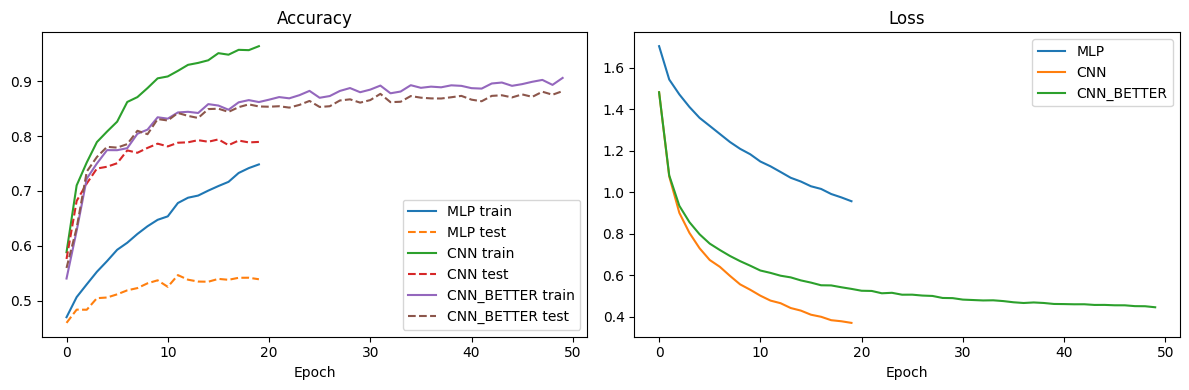

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name, (train_accs, test_accs, losses, g_model) in results.items():
    ax1.plot(train_accs, label=f'{name} train')
    ax1.plot(test_accs, label=f'{name} test', linestyle='--')
    ax2.plot(losses, label=name)

ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.tight_layout()
plt.show()

In [54]:
def evaluate_full(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            probs = model.predict_proba(images)
            preds = model.predict(images)
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    return (
        np.concatenate(all_probs),
        np.concatenate(all_preds),
        np.concatenate(all_labels)
    )

for name, (train_accs, test_accs, losses, g_model) in results.items():
    y_probs, y_preds, y_true = evaluate_full(g_model, testloader)
    acc = accuracy_score(y_true, y_preds)
    auroc = roc_auc_score(y_true, y_probs, multi_class='ovr')
    print(f"{name} | Accuracy: {acc:.2%} | AUROC: {auroc:.2%}")

MLP | Accuracy: 53.88% | AUROC: 89.60%
CNN | Accuracy: 78.94% | AUROC: 97.61%
CNN_BETTER | Accuracy: 79.73% | AUROC: 98.23%
